In [17]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

from jupyter_bbox_widget import BBoxWidget
import ipywidgets as widgets
from io import BytesIO
from PIL import Image
import HelperFunctions
from src import render
from src import postprocess as _postprocess


H_F = HelperFunctions.Helper_Functions()

/tmp/ipykernel_3484477/1598767892.py:26: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [39]:
image_folder = "/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/"
loc_files = H_F.file_search(image_folder, ".h5", "")

In [40]:
loc_files

['/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/1nM_NR4A_650200BP_515LP_1/Localisations.h5',
 '/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/1nM_NR4A_650200BP_515LP_HILO_1/Localisations.h5',
 '/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/10pM_NR4A_650200BP_515LP_1/Localisations.h5',
 '/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/100pM_NR4A_650200BP_515LP_HILO_1/Localisations.h5',
 '/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/500pM_NR4A_650200BP_515LP_HILO_1/Localisations.h5',
 '/media/jbeckwith/Ezra Seagat/20251128_SAureus/data/500pM_NR4A_650200BP_515LP_HILO_2/Localisations.h5']

In [13]:
def trim_locs(loc_data):
    loc_data = loc_data[loc_data["xc_err"] < 1]
    loc_data = loc_data[loc_data["yc_err"] < 1]
    
    loc_data = loc_data[loc_data["xc_err"] > 0]
    loc_data = loc_data[loc_data["yc_err"] > 0]
    
    loc_data = loc_data[loc_data["s_x_err"] < 1]
    loc_data = loc_data[loc_data["s_y_err"] < 1]
    
    loc_data = loc_data[loc_data["A_B_err"] < 0.15]
    loc_data = loc_data[loc_data["A_G_err"] < 0.15]
    loc_data = loc_data[loc_data["A_R_err"] < 0.15]
    
    loc_data = loc_data[loc_data["A_B"] > 0.005]
    loc_data = loc_data[loc_data["A_G"] > 0.01]
    loc_data = loc_data[loc_data["A_R"] > 0.01]
    
    loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
    loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
    loc_data = loc_data[loc_data["bg_R_err"] < 0.15]
    
    loc_data = loc_data[loc_data["photons"] < 100000]
    loc_data = loc_data[loc_data["photons"] > 100]
    
    
    loc_data = loc_data[loc_data["chi_sqr"] < 2]
    return loc_data

In [27]:
TIRF_1nM = pd.read_hdf(loc_files[0])
TIRF_1nM = trim_locs(TIRF_1nM)

TIRF_10pM = pd.read_hdf(loc_files[2])
TIRF_10pM = trim_locs(TIRF_10pM)

HILO_1nM = pd.read_hdf(loc_files[1])
HILO_1nM = trim_locs(HILO_1nM)

HILO_100pM = pd.read_hdf(loc_files[3])
HILO_100pM = trim_locs(HILO_100pM)

HILO_500pM = pd.read_hdf(loc_files[5])
HILO_500pM = trim_locs(HILO_500pM)

In [116]:
oversampling=8

image_TIRF_1nM = render.render(
    locs=TIRF_1nM.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(TIRF_1nM['yc']), np.max(TIRF_1nM['xc']))),
    blur_method="smooth",
)[1]

image_TIRF_10pM = render.render(
    locs=TIRF_10pM.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(TIRF_10pM['yc']), np.max(TIRF_10pM['xc']))),
    blur_method="smooth",
)[1]

image_HILO_1nM = render.render(
    locs=HILO_1nM.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(HILO_1nM['yc']), np.max(HILO_1nM['xc']))),
    blur_method="smooth",
)[1]

image_HILO_100pM = render.render(
    locs=HILO_100pM.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(HILO_100pM['yc']), np.max(HILO_100pM['xc']))),
    blur_method="smooth",
)[1]

image_HILO_500pM = render.render(
    locs=HILO_500pM.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(HILO_500pM['yc']), np.max(HILO_500pM['xc']))),
    blur_method="smooth",
)[1]

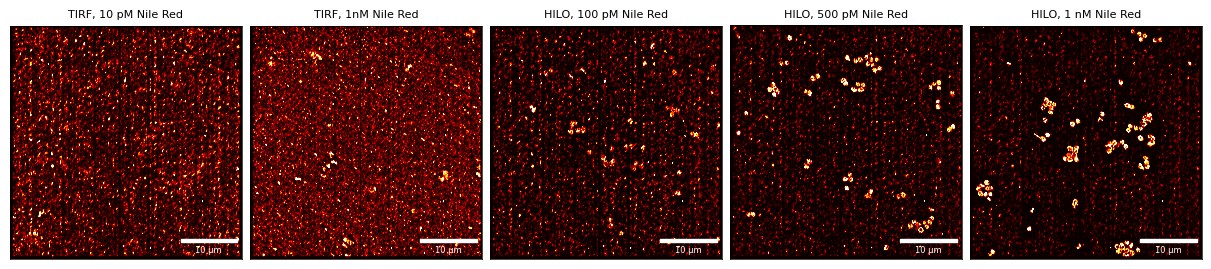

In [117]:
fig, axs = plotter.two_column_plot(ncolumns=5, widthratio=[1,1,1,1,1], width=12)


axs[0] = plotter.image_plot(axs[0], image_TIRF_10pM, cbar='off', cmap='hot', pixelsize=69/oversampling)
axs[0].set_title('TIRF, 10 pM Nile Red')

axs[1] = plotter.image_plot(axs[1], image_TIRF_1nM, cbar='off', cmap='hot', pixelsize=69/oversampling)
axs[1].set_title('TIRF, 1nM Nile Red')

axs[2] = plotter.image_plot(axs[2], image_HILO_100pM, cbar='off', cmap='hot', pixelsize=69/oversampling)
axs[2].set_title('HILO, 100 pM Nile Red')

axs[3] = plotter.image_plot(axs[3], image_HILO_500pM, cbar='off', cmap='hot', pixelsize=69/oversampling)
axs[3].set_title('HILO, 500 pM Nile Red')

axs[4] = plotter.image_plot(axs[4], image_HILO_1nM, cbar='off', cmap='hot', pixelsize=69/oversampling)
axs[4].set_title('HILO, 1 nM Nile Red')


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/SAureus/'
plt.savefig(os.path.join(folder, 'Different_Conditions.svg'), dpi=600, format='svg')
plt.show()


Processing: HILO 1 nM
Loaded 377572 localizations
Image dimensions: 608 x 612 pixels
Step 1/5: Rendering super-resolved image...
Step 2/5: Applying li thresholding...
Step 3/5: Detecting connected regions...
Step 4/5: Filtering aggregates by size and localisation count...


/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/src/PlottingBase.py:258: UserWarning: Width 8.00" exceeds one-column standard (3.33")
  warnings.warn(
Traceback (most recent call last):
  File "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/superres_notebooks/../src/postprocess.py", line 2344, in segment_locs_by_rendered_image
    plt.tight_layout()
  File "/home/jbeckwith/.virtualenvs/pyBayerSMLM/lib/python3.12/site-packages/matplotlib/pyplot.py", line 2599, in tight_layout
    gcf().tight_layout(pad=pad, h_pad=h_pad, w_pad=w_pad, rect=rect)
  File "/home/jbeckwith/.virtualenvs/pyBayerSMLM/lib/python3.12/site-packages/matplotlib/figure.py", line 3539, in tight_layout
    self.set_layout_engine(engine)
  File "/home/jbeckwith/.virtualenvs/pyBayerSMLM/lib/python3.12/site-packages/matplotlib/figure.py", line 2674, in set_layout_engine
    raise RuntimeError('Colorbar layout of new layout engine not '
RuntimeError: Colorbar layout of new layo

Found 50 valid aggregates (from 1582 total regions)
Step 5/5: Extracting localisations and computing statistics...
✓ Complete! Extracted 168493 localisations in 50 aggregates                     4.67it/s]

✓ Results saved successfully
  Aggregates found: 50
  Localizations in bacteria: 168493 (44.6%)
  Mean area: 0.75 µm²
  Mean locs/aggregate: 3370


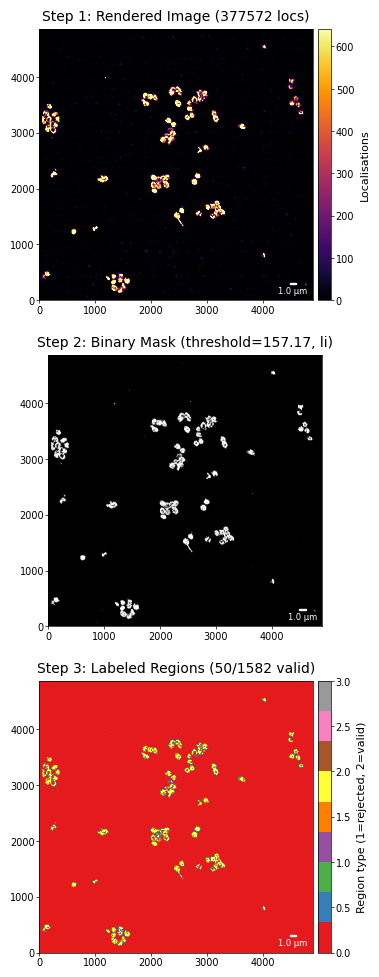

In [54]:
# Memory-efficient aggregate detection using image-based segmentation
# This replaces the DBSCAN + ConvexHull approach with a much more memory-efficient method

# Define parameters
MIN_AREA_NM2 = 100000.0  # Minimum area threshold in nm² (50000 nm² = 0.05 µm²)
MIN_LOCS = 20      # Minimum localizations per bacterium
PIXEL_SIZE_NM = 69.0  # Camera pixel size in nanometers
OVERSAMPLING = 8      # Super-resolution rendering oversampling


print(f"\n{'='*70}")
print(f"Processing: HILO 1 nM")
print(f"{'='*70}")

# Load data
print(f"Loaded {len(HILO_1nM)} localizations")

# Get image dimensions from data
width = int(np.ceil(HILO_1nM["xc"].max())) + 10
height = int(np.ceil(HILO_1nM["yc"].max())) + 10
print(f"Image dimensions: {width} x {height} pixels")

# Run memory-efficient segmentation
# This uses image thresholding instead of DBSCAN - MUCH more memory efficient!
aggregate_locs, per_aggregate_stats = _postprocess.segment_locs_by_rendered_image(
    HILO_1nM,
    width=width,
    height=height,
    oversampling=OVERSAMPLING,
    pixel_size_nm=PIXEL_SIZE_NM,
    min_area_nm2=MIN_AREA_NM2,
    min_localisations=MIN_LOCS,
    threshold_method='li',  # Li thresholding works well for bacterial imaging
    callback='console',
    blur_method='gaussian',
    verbose=True,
)

# Rename columns to match expected output format
aggregate_locs_HILO_1nM = aggregate_locs.rename(
    columns={'aggregate_id': 'cluster_id', 'aggregate_area_nm2': 'cluster_area_nm2'}
)
per_aggregate_stats_HILO_1nM = per_aggregate_stats.rename(
    columns={'aggregate_id': 'cluster_id'}
)

# Print summary
print(f"\n✓ Results saved successfully")
print(f"  Bacteria found: {len(per_aggregate_stats_HILO_1nM)}")
print(f"  Localisations in bacteria: {len(aggregate_locs_HILO_1nM)} "
      f"({100 * len(aggregate_locs_HILO_1nM) / len(HILO_1nM):.1f}%)")
print(f"  Mean area: {per_aggregate_stats_HILO_1nM['area_nm2'].mean() / 1e6:.2f} µm²")
print(f"  Mean locs/bacteria: {per_aggregate_stats_HILO_1nM['n_localisations'].mean():.0f}")



Processing: HILO 500pM
Loaded 320898 localizations
Image dimensions: 604 x 609 pixels
Step 1/5: Rendering super-resolved image...
Step 2/5: Applying li thresholding...
Step 3/5: Detecting connected regions...
Step 4/5: Filtering aggregates by size and localisation count...


/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/src/PlottingBase.py:258: UserWarning: Width 8.00" exceeds one-column standard (3.33")
  warnings.warn(
Traceback (most recent call last):
  File "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/superres_notebooks/../src/postprocess.py", line 2344, in segment_locs_by_rendered_image
    plt.tight_layout()
  File "/home/jbeckwith/.virtualenvs/pyBayerSMLM/lib/python3.12/site-packages/matplotlib/pyplot.py", line 2599, in tight_layout
    gcf().tight_layout(pad=pad, h_pad=h_pad, w_pad=w_pad, rect=rect)
  File "/home/jbeckwith/.virtualenvs/pyBayerSMLM/lib/python3.12/site-packages/matplotlib/figure.py", line 3539, in tight_layout
    self.set_layout_engine(engine)
  File "/home/jbeckwith/.virtualenvs/pyBayerSMLM/lib/python3.12/site-packages/matplotlib/figure.py", line 2674, in set_layout_engine
    raise RuntimeError('Colorbar layout of new layout engine not '
RuntimeError: Colorbar layout of new layo

Found 54 valid aggregates (from 987 total regions)
Step 5/5: Extracting localisations and computing statistics...
✓ Complete! Extracted 95804 localisations in 54 aggregates                      2.74it/s]

✓ Results saved successfully
  Aggregates found: 54
  Localizations in bacteria: 95804 (29.9%)
  Mean area: 0.51 µm²
  Mean locs/aggregate: 1774


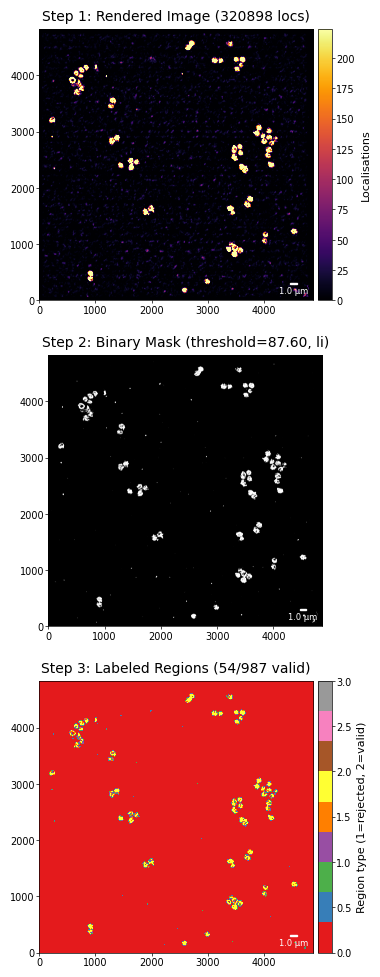

In [55]:
# Memory-efficient aggregate detection using image-based segmentation
# This replaces the DBSCAN + ConvexHull approach with a much more memory-efficient method

# Define parameters
MIN_AREA_NM2 = 100000.0  # Minimum area threshold in nm² (50000 nm² = 0.05 µm²)
MIN_LOCS = 20      # Minimum localizations per bacterium
PIXEL_SIZE_NM = 69.0  # Camera pixel size in nanometers
OVERSAMPLING = 8      # Super-resolution rendering oversampling


print(f"\n{'='*70}")
print(f"Processing: HILO 500pM")
print(f"{'='*70}")

# Load data
print(f"Loaded {len(HILO_500pM)} localizations")

# Get image dimensions from data
width = int(np.ceil(HILO_500pM["xc"].max())) + 10
height = int(np.ceil(HILO_500pM["yc"].max())) + 10
print(f"Image dimensions: {width} x {height} pixels")

# Run memory-efficient segmentation
# This uses image thresholding instead of DBSCAN - MUCH more memory efficient!
aggregate_locs, per_aggregate_stats = _postprocess.segment_locs_by_rendered_image(
    HILO_500pM,
    width=width,
    height=height,
    oversampling=OVERSAMPLING,
    pixel_size_nm=PIXEL_SIZE_NM,
    min_area_nm2=MIN_AREA_NM2,
    min_localisations=MIN_LOCS,
    threshold_method='li',  # Li thresholding works well for bacterial imaging
    callback='console',
    blur_method='gaussian',
    verbose=True,
)

# Rename columns to match expected output format
aggregate_locs_HILO_500pM = aggregate_locs.rename(
    columns={'aggregate_id': 'cluster_id', 'aggregate_area_nm2': 'cluster_area_nm2'}
)
per_aggregate_stats_HILO_500pM = per_aggregate_stats.rename(
    columns={'aggregate_id': 'cluster_id'}
)

# Print summary
print(f"\n✓ Results saved successfully")
print(f"  Aggregates found: {len(per_aggregate_stats_HILO_500pM)}")
print(f"  Localizations in bacteria: {len(aggregate_locs_HILO_500pM)} "
      f"({100 * len(aggregate_locs_HILO_500pM) / len(HILO_500pM):.1f}%)")
print(f"  Mean area: {per_aggregate_stats_HILO_500pM['area_nm2'].mean() / 1e6:.2f} µm²")
print(f"  Mean locs/aggregate: {per_aggregate_stats_HILO_500pM['n_localisations'].mean():.0f}")


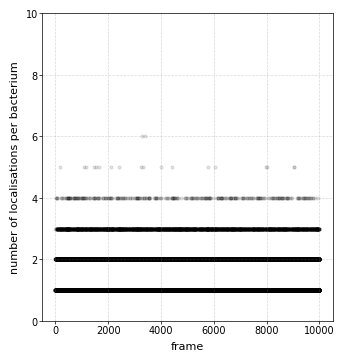

In [109]:
cluster_ids_1nM = np.unique(aggregate_locs_HILO_1nM['cluster_id'])

fig, axs = plotter.one_column_plot()

for id in cluster_ids_1nM:
    data = aggregate_locs_HILO_1nM[aggregate_locs_HILO_1nM['cluster_id'] == id].groupby('frame').count()
    axs = plotter.scatter_plot(axs, x=np.asarray(data.index), y=data['xc'], yaxislabel='number of localisations per bacterium', xaxislabel='frame', alpha=0.1)
axs.set_ylim([0, 10])

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/SAureus/'
plt.savefig(os.path.join(folder, 'HILO_1nM_perframe.svg'), dpi=600, format='svg')
plt.show()

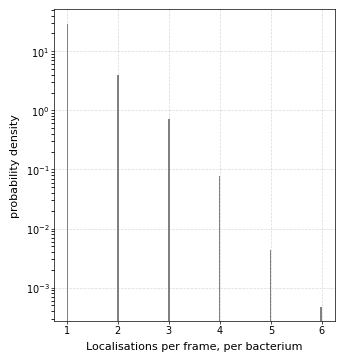

In [123]:
data = aggregate_locs_HILO_1nM.groupby(['cluster_id', 'frame']).count()['xc']

fig, axs = plotter.one_column_plot()


axs= plotter.histogram_plot(axs, data, np.histogram_bin_edges(data, 'scott'), density=True, xaxislabel='Localisations per frame, per bacterium')
axs.set_yscale('log')
plt.savefig(os.path.join(folder, 'HILO_1nM_perframe_histogram.svg'), dpi=600, format='svg')
plt.show()

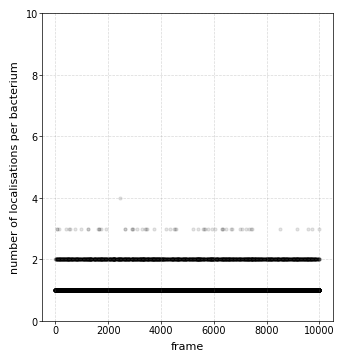

In [112]:
cluster_ids_500pM = np.unique(aggregate_locs_HILO_500pM['cluster_id'])

fig, axs = plotter.one_column_plot()

for id in cluster_ids_500pM:
    data = aggregate_locs_HILO_500pM[aggregate_locs_HILO_500pM['cluster_id'] == id].groupby('frame').count()
    axs = plotter.scatter_plot(axs, x=np.asarray(data.index), y=data['xc'], yaxislabel='number of localisations per bacterium', xaxislabel='frame', alpha=0.1)
axs.set_ylim([0, 10])

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20260205/fig/SAureus/'
plt.savefig(os.path.join(folder, 'HILO_500pM_perframe.svg'), dpi=600, format='svg')
plt.show()

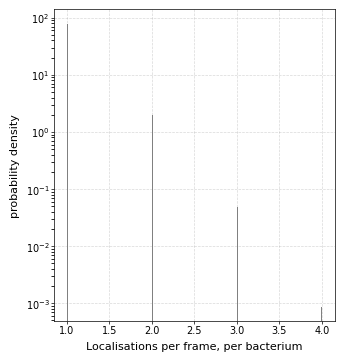

In [122]:
data = aggregate_locs_HILO_500pM.groupby(['cluster_id', 'frame']).count()['xc']

fig, axs = plotter.one_column_plot()


axs= plotter.histogram_plot(axs, data, np.histogram_bin_edges(data, 'scott'), density=True, xaxislabel='Localisations per frame, per bacterium')
axs.set_yscale('log')
plt.savefig(os.path.join(folder, 'HILO_500pM_perframe_histogram.svg'), dpi=600, format='svg')
plt.show()